<a href="https://colab.research.google.com/github/muhammedriswanp/ai-ml-learning-lab/blob/main/week5_genai_langchain_agents_multimodal/day23_multimodal_llms.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install transformers accelerate Pillow requests -q

In [3]:
import requests
from PIL import Image
from io import BytesIO
import torch
from transformers import Blip2Processor, Blip2ForConditionalGeneration
import matplotlib.pyplot as plt


In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
print( f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")

Using device: cuda
GPU: Tesla T4


# Blip2Processor (Input Preparation)

**Role:** Prepares raw image and text into the format expected by the BLIP-2 model.

```text
Raw Image + Text
        │
        ▼
Blip2Processor
        │
        ├── Resize image
        ├── Normalize pixels
        ├── Convert image → Tensor
        ├── Tokenize text
        ├── Convert text → Token IDs
        └── Create attention masks
        │
        ▼
Model-ready tensors
```

> **Note:** `Blip2Processor` **does NOT** extract image features or embeddings. It only prepares the inputs for the model.

# Blip2ForConditionalGeneration (The Neural Network)

**Role:** Understands the processed image and text, then generates a caption or answer.

```text
Model-ready tensors
        │
        ▼
Vision Encoder (ViT)
        │
Extract visual features
        │
        ▼
Image Embeddings
        │
        ▼
Q-Former
        │
Select important visual information
        │
        ▼
Projection Layer
        │
Convert to LLM embedding space
        │
        ▼
LLM (OPT)
        │
Generate text token by token
        │
        ▼
Caption / Answer
```

> **Note:** `Blip2ForConditionalGeneration` contains the complete BLIP-2 architecture (Vision Encoder + Q-Former + Projection Layer + LLM) and performs the actual image understanding and text generation.

In [5]:
processor = Blip2Processor.from_pretrained("Salesforce/blip2-opt-2.7b")

model = Blip2ForConditionalGeneration.from_pretrained(
    "Salesforce/blip2-opt-2.7b",
    torch_dtype=torch.float16,
    device_map="auto"
)

model.eval()
print("✅ Model loaded successfully!")

processor_config.json:   0%|          | 0.00/68.0 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/432 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.03k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/882 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/798k [00:00<?, ?B/s]

...

model.safetensors.index.json:   0%|          | 0.00/122k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1247 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/141 [00:00<?, ?B/s]

✅ Model loaded successfully!


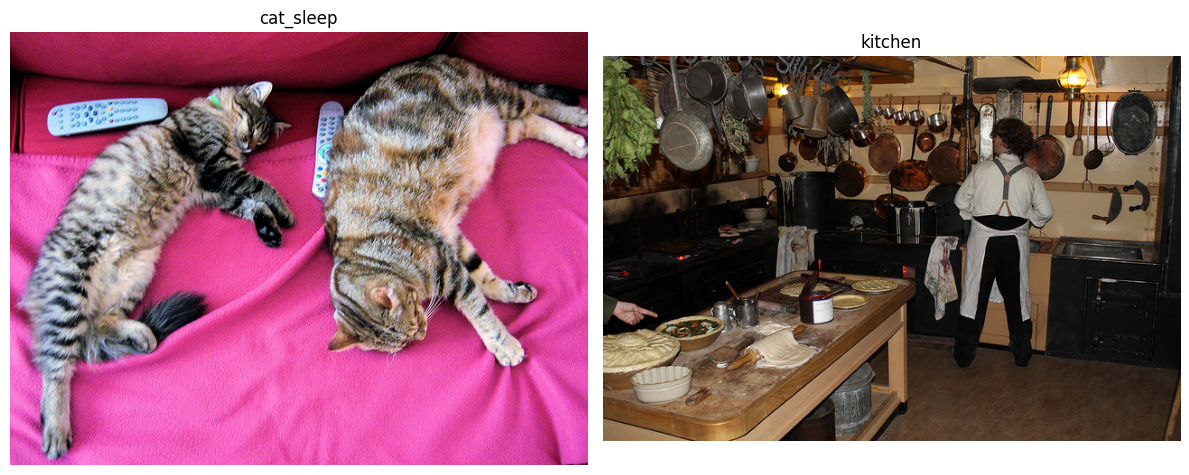

✅ Images loaded!


In [6]:
IMAGES = {
    "cat_sleep": "http://images.cocodataset.org/val2017/000000039769.jpg",
    "kitchen":       "http://images.cocodataset.org/val2017/000000397133.jpg"
}

def load_image_from_url(url):
  response = requests.get(url)
  image = Image.open(BytesIO(response.content)).convert("RGB")
  return image


images = {name: load_image_from_url(url) for name, url in IMAGES.items()}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (name, img) in zip(axes, images.items()):
    ax.imshow(img)
    ax.set_title(name)
    ax.axis("off")
plt.tight_layout()
plt.show()

print("✅ Images loaded!")


In [7]:
def generate_caption(image, prompt=None):
  if prompt:
    inputs = processor(image, text=prompt, return_tensors="pt").to(device, torch.float16)
  else:
    inputs = processor(image, return_tensors="pt").to(device, torch.float16)

  with torch.no_grad():
    outputs = model.generate(**inputs, max_new_tokens=50)

  caption = processor.decode(outputs[0], skip_special_tokens=True)
  return caption

# Generate captions for both images
for name, image in images.items():
    caption = generate_caption(image)
    print(f"🖼️  {name}: {caption}")

🖼️  cat_sleep: two cats laying on a couch

🖼️  kitchen: a woman in a kitchen with a man in a kitchen



In [12]:
def ask_question(image, question):
    prompt = f"Question: {question} Answer:"
    inputs = processor(image, text=prompt, return_tensors="pt").to(device, torch.float16)

    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=30
        )

    answer = processor.decode(output[0], skip_special_tokens=True)
    answer = answer.split("Answer:")[-1].strip()
    return answer

# Ask questions about the cat image
print("🐱 CAT IMAGE")
print("-" * 40)
questions_cat = [
    "How many cats are in the image?",
    "What are the cats doing?",
    "What color are the cats?",
    "Where are the cats sitting?",
]
for q in questions_cat:
    answer = ask_question(images["cat_sleep"], q)
    print(f"Q: {q}")
    print(f"A: {answer}\n")

🐱 CAT IMAGE
----------------------------------------
Q: How many cats are in the image?
A: Two

Q: What are the cats doing?
A: Sleeping

Q: What color are the cats?
A: They are all different colors

Q: Where are the cats sitting?
A: On the couch



In [13]:
print("🍳 KITCHEN IMAGE")
print("-" * 40)
questions_kitchen = [
    "How many people are in the image?",
    "What is the person doing?",
    "What objects are on the counter?",
    "Is this a modern or old kitchen?",
]
for q in questions_kitchen:
    answer = ask_question(images["kitchen"], q)
    print(f"Q: {q}")
    print(f"A: {answer}\n")

🍳 KITCHEN IMAGE
----------------------------------------
Q: How many people are in the image?
A: Two

Q: What is the person doing?
A: Cooking

Q: What objects are on the counter?
A: Pot holders

Q: Is this a modern or old kitchen?
A: It's a kitchen



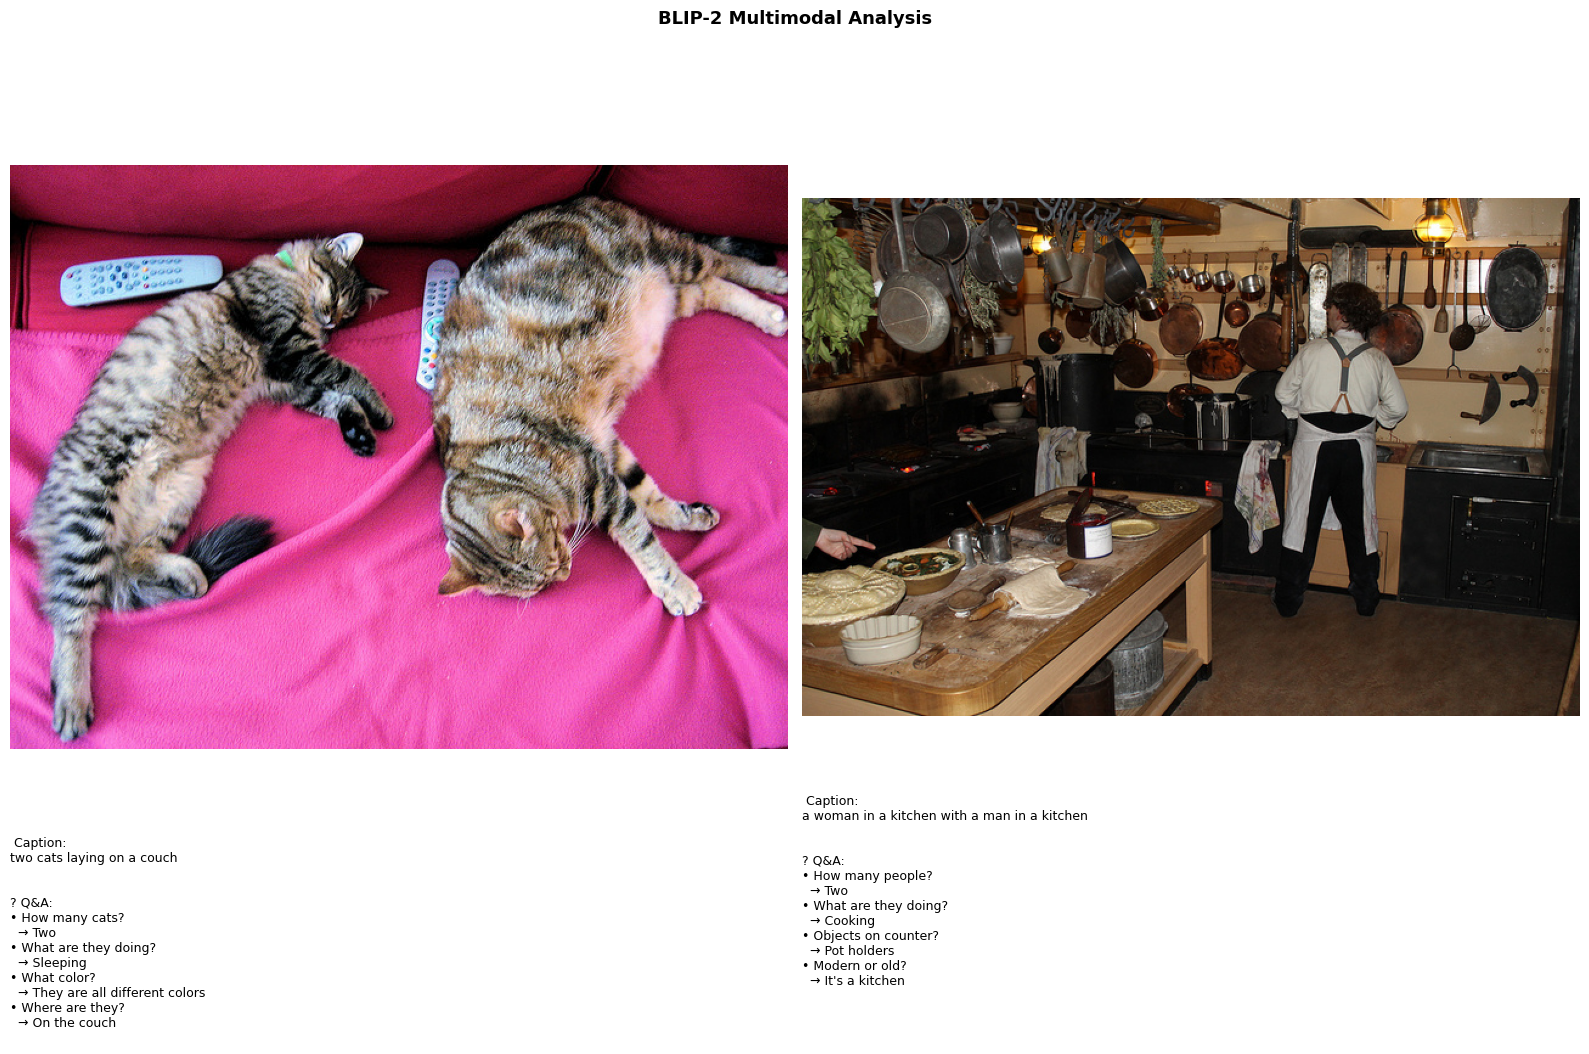

Saved as day23_multimodal_output.png


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 10))

results = {
    "cat_sleep": {
        "image": images["cat_sleep"],
        "caption": generate_caption(images["cat_sleep"]),
        "qa": [
            ("How many cats?", ask_question(images["cat_sleep"], "How many cats are in the image?")),
            ("What are they doing?", ask_question(images["cat_sleep"], "What are the cats doing?")),
            ("What color?", ask_question(images["cat_sleep"], "What color are the cats?")),
            ("Where are they?", ask_question(images["cat_sleep"], "Where are the cats sitting?")),
        ]
    },
    "kitchen": {
        "image": images["kitchen"],
        "caption": generate_caption(images["kitchen"]),
        "qa": [
            ("How many people?", ask_question(images["kitchen"], "How many people are in the image?")),
            ("What are they doing?", ask_question(images["kitchen"], "What is the person doing?")),
            ("Objects on counter?", ask_question(images["kitchen"], "What objects are on the counter?")),
            ("Modern or old?", ask_question(images["kitchen"], "Is this a modern or old kitchen?")),
        ]
    }
}

for ax, (name, data) in zip(axes, results.items()):
    ax.imshow(data["image"])
    ax.axis("off")

    text = f" Caption:\n{data['caption']}\n\n? Q&A:\n"
    for q, a in data["qa"]:
        text += f"• {q}\n  → {a}\n"

    ax.text(0, -0.15, text, transform=ax.transAxes,
            fontsize=9, va='top', ha='left', wrap=True)

plt.suptitle("BLIP-2 Multimodal Analysis", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("day23_multimodal_output.png", bbox_inches="tight", dpi=150)
plt.show()